# Space Invaders A2C CNN v1 - Basic

Simplified Advantage Actor-Critic (A2C) implementation for Atari Space Invaders.

## Simplifications:
- **No GAE**: Uses simple n-step returns
- **All code inline**: No external utility modules
- **Basic advantages**: advantages = returns - values
- **Stochastic policy** with categorical distribution
- **Shared CNN** features for both actor and critic

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import random
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython.display import clear_output
from collections import deque
import cv2
import mlflow
import mlflow.pytorch
import wandb
import os
from dotenv import load_dotenv
from pathlib import Path

# Import logging utilities
from logging_utils import (
    log_hyperparameters,
    log_model_info,
    log_episode_metrics,
    log_a2c_losses,
    save_checkpoint,
    save_training_plot,
    display_training_plot,
    log_final_results,
    setup_weight_tracking,
    log_layer_wise_gradient_norms,
    log_weight_stats
)

import ale_py
gym.register_envs(ale_py)

## Reproducibility

In [2]:
SEED = 24127

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"Random seed set to: {SEED}")

Random seed set to: 24127


## Preprocessing Functions

In [3]:
def preprocess_frame(frame):
    """Convert frame to grayscale, crop, resize to 84x84, and normalize."""
    gray = np.mean(frame, axis=2).astype(np.uint8)
    cropped = gray[34:194, :]
    resized = cv2.resize(cropped, (84, 84), interpolation=cv2.INTER_AREA)
    return resized.astype(np.float32) / 255.0


class FrameStack:
    """Stack multiple consecutive frames to capture temporal information."""
    def __init__(self, num_frames=2):
        self.num_frames = num_frames
        self.frames = deque(maxlen=num_frames)

    def reset(self, frame):
        processed_frame = preprocess_frame(frame)
        for _ in range(self.num_frames):
            self.frames.append(processed_frame)
        return self.get_stacked()

    def step(self, frame):
        processed_frame = preprocess_frame(frame)
        self.frames.append(processed_frame)
        return self.get_stacked()

    def get_stacked(self):
        return np.stack(list(self.frames), axis=0)

## A2C Network

In [4]:
class A2CAgent(nn.Module):
    """A2C Agent with shared CNN features, actor head, and critic head."""
    
    def __init__(self, input_channels, action_size):
        super(A2CAgent, self).__init__()
        
        # Shared CNN feature extractor (32→64→64 filters, matching Defender DQN)
        self.conv = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=8, stride=4, padding=2),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU()
        )
        
        # Calculate feature size
        self.feature_size = self._get_conv_output_size(input_channels)
        
        # Actor head (policy)
        self.actor_fc = nn.Linear(self.feature_size, 512)
        self.policy_head = nn.Linear(512, action_size)
        
        # Critic head (value)
        self.critic_fc = nn.Linear(self.feature_size, 512)
        self.value_head = nn.Linear(512, 1)
        
        self.action_size = action_size
    
    def _get_conv_output_size(self, input_channels):
        """Calculate the output size of conv layers."""
        with torch.no_grad():
            dummy_input = torch.zeros(1, input_channels, 84, 84)
            conv_output = self.conv(dummy_input)
            return conv_output.numel() // conv_output.size(0)
    
    def forward(self, state):
        """Forward pass: returns policy logits and value estimate."""
        # Shared CNN features
        features = self.conv(state)
        features = features.view(features.size(0), -1)
        
        # Actor: policy logits
        actor_hidden = F.relu(self.actor_fc(features))
        logits = self.policy_head(actor_hidden)
        
        # Critic: value estimate
        critic_hidden = F.relu(self.critic_fc(features))
        value = self.value_head(critic_hidden).squeeze(-1)
        
        return logits, value
    
    def get_action(self, state):
        """Sample action from policy and return action, log_prob, value."""
        logits, value = self.forward(state)
        probs = F.softmax(logits, dim=-1)
        
        # Sample action from categorical distribution
        dist = torch.distributions.Categorical(probs)
        action = dist.sample()
        
        # Get log probability
        log_prob = dist.log_prob(action)
        
        return action, log_prob, value

## Simple Returns Computation

In [5]:
def compute_returns(rewards, gamma=0.99, next_value=0.0):
    """Compute n-step returns using simple discounting."""
    returns = []
    R = next_value
    
    # Calculate returns backwards
    for reward in reversed(rewards):
        R = reward + gamma * R
        returns.insert(0, R)
    
    return np.array(returns, dtype=np.float32)

## Hyperparameters and Setup

In [6]:
# A2C Hyperparameters - FIXED for Atari games
LEARNING_RATE = 0.00007  # Reduced from 0.0001 for stability
GAMMA = 0.99
N_STEPS = 20  # Increased from 5 for better temporal credit assignment
VALUE_LOSS_COEF = 0.5
ENTROPY_COEF = 0.03  # Increased from 0.01 for better exploration
MAX_GRAD_NORM = 5.0  # CRITICAL FIX: Increased from 0.5 to allow learning
MEAN_REWARD_BOUND = 500  # Space Invaders reward threshold (much lower than Defender)

# Environment parameters
FRAME_SKIP = 4
INPUT_CHANNELS = 2

# Logging
LOG_FREQ = 100
CHECKPOINT_FREQ = 5000  # More frequent for Space Invaders
GRADIENT_LOG_FREQ = 500

# Architecture
ARCHITECTURE_NAME = "CNN-A2C-SpaceInvaders"
MODEL_FILTERS = "32-64-64"

# Hyperparameters dict
HYPERPARAMETERS = {
    "seed": SEED,
    "learning_rate": LEARNING_RATE,
    "gamma": GAMMA,
    "n_steps": N_STEPS,
    "value_loss_coef": VALUE_LOSS_COEF,
    "entropy_coef": ENTROPY_COEF,
    "max_grad_norm": MAX_GRAD_NORM,
    "mean_reward_bound": MEAN_REWARD_BOUND,
    "frame_skip": FRAME_SKIP,
    "input_channels": INPUT_CHANNELS,
    "architecture": ARCHITECTURE_NAME,
    "model_filters": MODEL_FILTERS,
    "log_freq": LOG_FREQ,
    "gradient_log_freq": GRADIENT_LOG_FREQ,
    "game": "SpaceInvaders",
    "reward_clipping": True,  # NEW: Added reward clipping flag
    "value_normalization": True  # NEW: Added value normalization flag
}

# Setup directories
RL_STUDY_DIR = Path.cwd().parent.parent if Path.cwd().name == 'space_invaders_a2c_cnn' else Path.cwd()
MLFLOW_TRACKING_URI = RL_STUDY_DIR / 'mlruns'
WANDB_DIR = RL_STUDY_DIR / 'wandb'
BASE_ARTIFACTS_DIR = RL_STUDY_DIR / 'artifacts'

# Create directories
WANDB_DIR.mkdir(exist_ok=True)
BASE_ARTIFACTS_DIR.mkdir(exist_ok=True)
MLFLOW_TRACKING_URI.mkdir(exist_ok=True)

# Configure MLflow
mlflow.set_tracking_uri(f'file://{MLFLOW_TRACKING_URI}')

# Configure wandb
os.environ['WANDB_DIR'] = str(WANDB_DIR)
load_dotenv(RL_STUDY_DIR / '.env')
wandb_key = os.getenv('WANDB_KEY')
wandb.login(key=wandb_key)

wandb.init(
    project="space_invaders_a2c_training",
    name="space_invaders_cnn_a2c_v1_fixed",  # Updated name to reflect fixes
    dir=str(WANDB_DIR),
    config=HYPERPARAMETERS
)

print(f"Setup complete!")
print(f"Random seed: {SEED}")
print(f"N-steps: {N_STEPS}, Gamma: {GAMMA}, LR: {LEARNING_RATE}")
print(f"Max Grad Norm: {MAX_GRAD_NORM}, Entropy Coef: {ENTROPY_COEF}")
print(f"Reward Clipping: Enabled, Value Normalization: Enabled")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /home/bmartins/.netrc
wandb: Currently logged in as: bmartins to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Setup complete!
Random seed: 24127
N-steps: 20, Gamma: 0.99, LR: 7e-05
Max Grad Norm: 5.0, Entropy Coef: 0.03
Reward Clipping: Enabled, Value Normalization: Enabled


## Training Function

In [7]:
def train_a2c():
    # End any active runs
    if mlflow.active_run():
        mlflow.end_run()
    
    # MLflow experiment setup
    mlflow.set_experiment("space_invaders_a2c_training")
    
    with mlflow.start_run():
        # Create artifacts directory
        run_id = mlflow.active_run().info.run_id
        artifacts_dir = BASE_ARTIFACTS_DIR / f"run_{run_id}"
        artifacts_dir.mkdir(parents=True, exist_ok=True)
        print(f"Artifacts will be saved to: {artifacts_dir}")
        
        # Log hyperparameters
        log_hyperparameters(HYPERPARAMETERS)
        
        # Environment setup
        env = gym.make('SpaceInvadersNoFrameskip-v4')
        env.reset(seed=SEED)
        action_size = env.action_space.n
        
        # Device
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Using device: {device}")
        
        # Create agent
        agent = A2CAgent(input_channels=INPUT_CHANNELS, action_size=action_size).to(device)
        optimizer = optim.Adam(agent.parameters(), lr=LEARNING_RATE)
        
        # Setup weight tracking
        setup_weight_tracking(agent, log_freq=GRADIENT_LOG_FREQ, log_all=True)
        
        # Log model info
        total_params = log_model_info(agent)
        print(f"Total parameters: {total_params:,}")
        
        # Training state
        episode_rewards = []
        episode = 0
        total_updates = 0
        
        print("Starting A2C training on Space Invaders with FIXED hyperparameters...\n")
        print(f"Key fixes: Grad Norm {MAX_GRAD_NORM}, N-steps {N_STEPS}, Entropy {ENTROPY_COEF}, Reward Clipping: ON\n")
        
        while True:
            # Reset environment
            state, _ = env.reset()
            frame_stack = FrameStack(INPUT_CHANNELS)
            stacked_state = frame_stack.reset(state)
            
            episode_reward = 0
            episode_reward_raw = 0  # Track unclipped rewards for logging
            episode_length = 0
            done = False
            
            episode_policy_losses = []
            episode_value_losses = []
            episode_entropy_losses = []
            episode_total_losses = []
            
            # Run episode
            while not done:
                # Collect N-step rollout
                states = []
                actions = []
                rewards = []
                
                for _ in range(N_STEPS):
                    # Get action from policy
                    state_tensor = torch.FloatTensor(stacked_state).unsqueeze(0).to(device)
                    
                    with torch.no_grad():
                        action, log_prob, value = agent.get_action(state_tensor)
                    
                    # Execute action with frame skip
                    step_reward = 0
                    for _ in range(FRAME_SKIP):
                        next_frame, reward, terminated, truncated, _ = env.step(action.item())
                        step_reward += reward
                        if terminated or truncated:
                            break
                    
                    # FIX 1: Clip rewards for stable learning
                    step_reward_clipped = np.clip(step_reward, -1.0, 1.0)
                    
                    # Store transition with clipped reward
                    states.append(stacked_state)
                    actions.append(action.item())
                    rewards.append(step_reward_clipped)
                    
                    # Track both clipped and raw rewards
                    episode_reward += step_reward_clipped
                    episode_reward_raw += step_reward
                    episode_length += 1
                    
                    # Update state
                    stacked_state = frame_stack.step(next_frame)
                    done = terminated or truncated
                    
                    if done:
                        break
                
                # Bootstrap value for next state
                if not done:
                    with torch.no_grad():
                        next_state_tensor = torch.FloatTensor(stacked_state).unsqueeze(0).to(device)
                        _, next_value = agent.forward(next_state_tensor)
                        next_value = next_value.item()
                else:
                    next_value = 0.0
                
                # Compute returns (no normalization - critic needs absolute scale)
                returns = compute_returns(rewards, gamma=GAMMA, next_value=next_value)
                
                # Convert to tensors
                states_tensor = torch.FloatTensor(np.array(states)).to(device)
                actions_tensor = torch.LongTensor(actions).to(device)
                returns_tensor = torch.FloatTensor(returns).to(device)
                
                # Forward pass
                logits, state_values = agent.forward(states_tensor)
                
                # Calculate advantages
                advantages = returns_tensor - state_values.detach()
                
                # Normalize advantages only (not returns)
                if len(advantages) > 1:
                    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
                
                # Get log probs and entropy
                probs = F.softmax(logits, dim=-1)
                log_probs_tensor = F.log_softmax(logits, dim=-1)
                action_log_probs = log_probs_tensor.gather(-1, actions_tensor.unsqueeze(-1)).squeeze(-1)
                entropy = -(probs * log_probs_tensor).sum(dim=-1).mean()
                
                # Compute losses
                policy_loss = -(action_log_probs * advantages).mean()
                value_loss = F.mse_loss(state_values, returns_tensor)
                entropy_loss = -entropy
                total_loss = policy_loss + VALUE_LOSS_COEF * value_loss + ENTROPY_COEF * entropy_loss
                
                # Backpropagation
                optimizer.zero_grad()
                total_loss.backward()
                # FIX 3: Increased gradient clipping to 5.0 (was 0.5)
                torch.nn.utils.clip_grad_norm_(agent.parameters(), MAX_GRAD_NORM)
                optimizer.step()
                
                # Store losses
                episode_policy_losses.append(policy_loss.item())
                episode_value_losses.append(value_loss.item())
                episode_entropy_losses.append(entropy_loss.item())
                episode_total_losses.append(total_loss.item())
                
                total_updates += 1
                
                # Log gradients periodically
                if total_updates % GRADIENT_LOG_FREQ == 0:
                    log_layer_wise_gradient_norms(agent, total_updates)
            
            # Episode finished - use raw unclipped reward for tracking progress
            episode_rewards.append(episode_reward_raw)
            mean_reward = np.mean(episode_rewards[-100:]) if len(episode_rewards) >= 100 else np.mean(episode_rewards)
            
            # Log episode metrics
            log_episode_metrics(episode_reward_raw, mean_reward, episode_length, episode, total_updates)
            
            # Log average losses
            if episode_total_losses:
                avg_policy_loss = np.mean(episode_policy_losses)
                avg_value_loss = np.mean(episode_value_losses)
                avg_entropy_loss = np.mean(episode_entropy_losses)
                avg_total_loss = np.mean(episode_total_losses)
                log_a2c_losses(avg_policy_loss, avg_value_loss, avg_entropy_loss, avg_total_loss, episode, total_updates)
            
            # Weight logging every LOG_FREQ episodes
            if episode % LOG_FREQ == 0 and episode > 0:
                log_weight_stats(agent, total_updates)
            
            # Print progress
            if episode % 10 == 0:
                avg_reward = np.mean(episode_rewards[-10:]) if len(episode_rewards) >= 10 else np.mean(episode_rewards)
                max_reward = max(episode_rewards) if episode_rewards else 0
                print(f"Episode {episode:4d} | Reward: {episode_reward_raw:6.1f} | Avg(10): {avg_reward:6.2f} | Mean(100): {mean_reward:6.2f} | Max: {max_reward:6.1f} | Updates: {total_updates}")
            
            # Plot every 100 episodes
            if episode % 100 == 0 and episode > 0:
                display_training_plot(episode_rewards, MEAN_REWARD_BOUND)
            
            # Save plot every 1000 episodes
            if episode > 0 and episode % 1000 == 0:
                save_training_plot(artifacts_dir, episode_rewards, episode, MEAN_REWARD_BOUND)
            
            # Save checkpoint
            if episode % CHECKPOINT_FREQ == 0 and episode > 0:
                save_checkpoint(artifacts_dir, episode, agent, optimizer, episode_rewards, run_id, total_updates)
            
            # Check stopping condition
            if mean_reward >= MEAN_REWARD_BOUND:
                print(f"\nEnvironment solved in {episode} episodes!")
                print(f"Mean reward: {mean_reward:.2f} >= {MEAN_REWARD_BOUND}")
                wandb.log({"solved_at_episode": episode}, step=total_updates)
                break
            
            episode += 1
        
        # Log final results
        final_model_path = log_final_results(agent, episode, mean_reward, episode_rewards, artifacts_dir, run_id)
        
        print(f"\nTraining completed!")
        print(f"Artifacts saved in: {artifacts_dir}")
        print(f"Total updates: {total_updates}")
        
        env.close()
        wandb.finish()
        return agent, episode_rewards

## Test Network Architecture

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


Input shape: torch.Size([1, 2, 84, 84])
Logits shape: torch.Size([1, 6])
Value: -0.0372
Action: 0
Log prob: -1.8443
Action space size (Space Invaders): 6

Total parameters: 6,632,103
Shared CNN: 73,888 (1.1%)
Actor: 3,280,390 (49.5%)
Critic: 3,277,825 (49.4%)


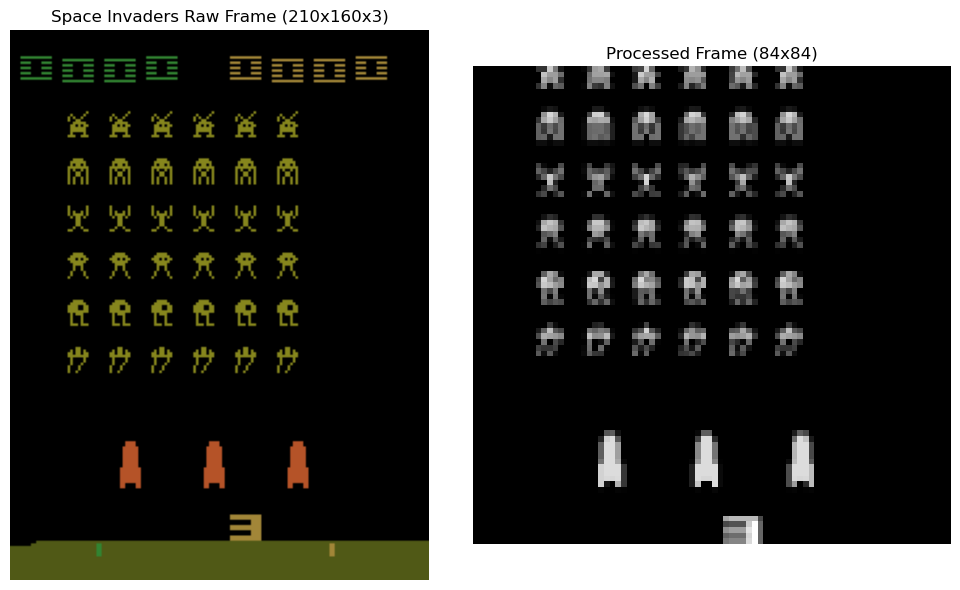

In [8]:
# Test the network
env = gym.make('SpaceInvadersNoFrameskip-v4')
state, _ = env.reset()

frame_stack = FrameStack(2)
stacked = frame_stack.reset(state)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_agent = A2CAgent(input_channels=2, action_size=env.action_space.n).to(device)

with torch.no_grad():
    state_tensor = torch.FloatTensor(stacked).unsqueeze(0).to(device)
    logits, value = test_agent(state_tensor)
    action, log_prob, _ = test_agent.get_action(state_tensor)
    
print(f"Input shape: {state_tensor.shape}")
print(f"Logits shape: {logits.shape}")
print(f"Value: {value.item():.4f}")
print(f"Action: {action.item()}")
print(f"Log prob: {log_prob.item():.4f}")
print(f"Action space size (Space Invaders): {env.action_space.n}")

total_params = sum(p.numel() for p in test_agent.parameters())
conv_params = sum(p.numel() for name, p in test_agent.named_parameters() if 'conv' in name)
actor_params = sum(p.numel() for name, p in test_agent.named_parameters() if 'actor' in name or 'policy' in name)
critic_params = sum(p.numel() for name, p in test_agent.named_parameters() if 'critic' in name or 'value' in name)

print(f"\nTotal parameters: {total_params:,}")
print(f"Shared CNN: {conv_params:,} ({conv_params/total_params*100:.1f}%)")
print(f"Actor: {actor_params:,} ({actor_params/total_params*100:.1f}%)")
print(f"Critic: {critic_params:,} ({critic_params/total_params*100:.1f}%)")

# Show a sample frame
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.imshow(state)
plt.title('Space Invaders Raw Frame (210x160x3)')
plt.axis('off')

plt.subplot(1, 2, 2)
processed = preprocess_frame(state)
plt.imshow(processed, cmap='gray')
plt.title('Processed Frame (84x84)')
plt.axis('off')
plt.tight_layout()
plt.show()

env.close()

## Start Training

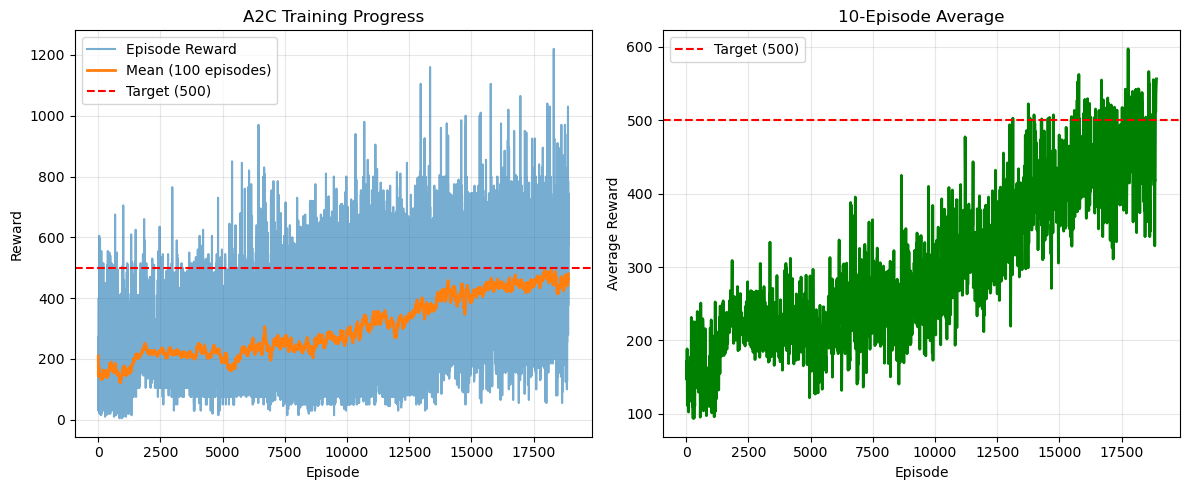

Episode 18910 | Reward:  410.0 | Avg(10): 481.50 | Mean(100): 480.45 | Max: 1220.0 | Updates: 604306
Episode 18920 | Reward:  610.0 | Avg(10): 484.00 | Mean(100): 484.45 | Max: 1220.0 | Updates: 604675
Episode 18930 | Reward:  420.0 | Avg(10): 455.50 | Mean(100): 497.30 | Max: 1220.0 | Updates: 605017
Episode 18940 | Reward:  415.0 | Avg(10): 452.00 | Mean(100): 496.20 | Max: 1220.0 | Updates: 605376
Episode 18950 | Reward:  555.0 | Avg(10): 442.00 | Mean(100): 499.80 | Max: 1220.0 | Updates: 605723


2026/01/15 20:04:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Environment solved in 18952 episodes!
Mean reward: 501.05 >= 500


2026/01/15 20:04:08 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0.dev20250930+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0.dev20250930' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/01/15 20:04:11 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0.dev20250930+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0.dev20250930' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/01/15 20:04:11 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



Training completed!
Artifacts saved in: /home/bmartins/dev/rl_study/artifacts/run_cd37374cfeb2442f8bce2ab2d6c9dac3
Total updates: 605802


final_episode,▁
final_mean_reward,▁
grad_norms/actor_fc.bias,▁▁▂▂▂▂▂▁▂▂▂▂▂▂▁▂▃▁▂▂▂▂█▂▂▄▆▁▃▅▅▂▄▃▄▂▂▂▂▇
grad_norms/actor_fc.weight,▂▂▁▂▃▂▁▁▁▂▂▁▂▂▃▃▂▁▃▇▄▃█▃▃▁▂▃▄█▁▄▆▇▃▇▁▄▄▃
grad_norms/conv.0.bias,▁▃▃▁▅▁▁▄▃▂▄▃▂▂▃▄▄▂▂▆▃▆▂▅▄▃▂▂▅▂▅▅▄▄▆█▅▅▃▂
grad_norms/conv.0.weight,▃▂▁█▁▄▂▄▆▂▄▄▁▂▃▂▂█▄▆▅▄▆▆▄▄▅▅▄▄▄▅▅▅▇▄▅▄▃▅
grad_norms/conv.2.bias,▂▁▁▂▃▃▄▂▂▁▃▅▆▃▄█▄▆▇▂█▇▅▆▆▂▅▇▅▃▄▅▂▃▄▄▆▅▇▄
grad_norms/conv.2.weight,▂▂▂▂▁▂▂▂▂▁▁▁▃▃▆▄▅▄▅▃▃▅▇▄▆▃█▄▄▅▆▆▅▃▅█▅▇▄▂
grad_norms/conv.4.bias,▂▂▂▃▁▂▃▄▃▂▃▂▁▂▅▃▁▇▃▄▆█▇▆▅▇▆█▆▄▆▇▆▄▂▃▇▃▆▄
grad_norms/conv.4.weight,▅▂▁▂▆▁▂▁▂▁▆▅▃▃▁▆▆▅▂▆▃█▃▇▃▅▆▄▃▅█▇▄▅▄▇▆▂▄▂
grad_norms/critic_fc.bias,▃▆▄▂▂▁▁▃▂▂▅▁▅▁█▂▆▅▁▁▅▄▅▂▂▅▃▄▄▁▄▆▂▅▄▅▁▅▅▅



Training completed!


In [9]:
# Ensure no active MLflow runs
if mlflow.active_run():
    print("Ending active MLflow run...")
    mlflow.end_run()

# Train the agent
trained_agent, rewards = train_a2c()
print("\nTraining completed!")

## Final Results Plot

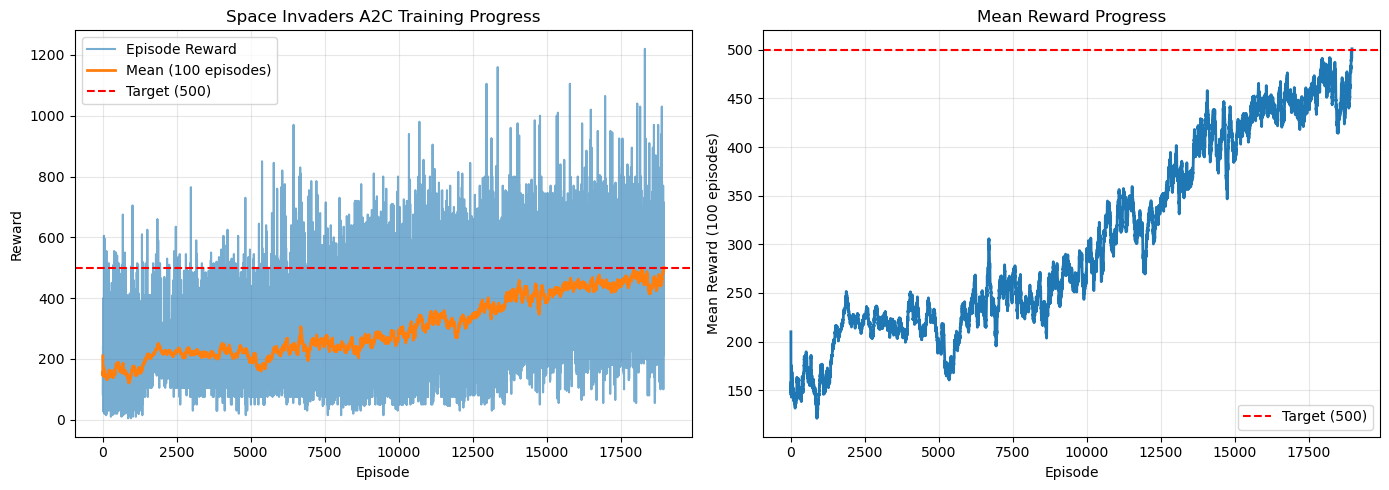

Final mean reward: 501.05
Max reward: 1220.00
Episodes trained: 18953


In [10]:
# Plot final results
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(rewards, alpha=0.6, label='Episode Reward')
if len(rewards) >= 100:
    moving_avg = [np.mean(rewards[max(0, i-99):i+1]) for i in range(len(rewards))]
    plt.plot(moving_avg, label='Mean (100 episodes)', linewidth=2)
plt.axhline(y=MEAN_REWARD_BOUND, color='r', linestyle='--', label=f'Target ({MEAN_REWARD_BOUND})')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Space Invaders A2C Training Progress')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
if len(rewards) >= 100:
    moving_avg = [np.mean(rewards[max(0, i-99):i+1]) for i in range(len(rewards))]
    plt.plot(moving_avg, linewidth=2)
    plt.axhline(y=MEAN_REWARD_BOUND, color='r', linestyle='--', label=f'Target ({MEAN_REWARD_BOUND})')
plt.xlabel('Episode')
plt.ylabel('Mean Reward (100 episodes)')
plt.title('Mean Reward Progress')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final mean reward: {np.mean(rewards[-100:]):.2f}")
print(f"Max reward: {max(rewards):.2f}")
print(f"Episodes trained: {len(rewards)}")